<a href="https://colab.research.google.com/github/srijanisinha/Quantitative-Market-Model-with-ROI-Backtesting/blob/main/end_to_end_pipeline_data_quality_framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Fetching data through python


In [17]:

!pip install yfinance

import yfinance as yf
import pandas as pd

print("EXTRACTING DATA")

ticker_symbol = "AAPL"
apple_stock = yf.Ticker(ticker_symbol)

raw_data = apple_stock.history(period="3mo", interval="1d")

raw_data = raw_data.reset_index()

print("Success! We pumped the raw data from the internet.")
raw_data.head()

EXTRACTING DATA
Success! We pumped the raw data from the internet.


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2026-04-06 00:00:00-04:00,256.273892,261.918685,256.223919,258.621704,29329900,0.0,0.0
1,2026-04-07 00:00:00-04:00,255.924218,255.964190,245.473839,253.266663,62148000,0.0,0.0
2,2026-04-08 00:00:00-04:00,258.212115,259.510906,256.293869,258.661682,41032800,0.0,0.0
3,2026-04-09 00:00:00-04:00,258.761595,260.879639,255.834299,260.250214,28121600,0.0,0.0
4,2026-04-10 00:00:00-04:00,259.740695,261.948652,258.781556,260.240234,31291500,0.0,0.0


## Data quality check

In [18]:
missing_data_count = raw_data.isnull().sum().sum()
print(missing_data_count)

lowest_price = raw_data['Close'].min()
print(lowest_price )

if missing_data_count > 0:
    print(f"Found {missing_data_count} missing boxes! Stop the pipeline!")

elif lowest_price < 0:
    print(f"Found a negative stock price ({lowest_price})! Stop!")

else:
    print("Data is perfect! Open the gates to the next step!")

0
253.26666259765625
Data is perfect! Open the gates to the next step!


## Extraction

In [19]:



raw_data['Daily_Return_Pct'] = raw_data['Close'].pct_change() * 100

raw_data['7Day_Moving_Average'] = raw_data['Close'].rolling(window=7).mean()

raw_data['7Day_Volatility'] = raw_data['Close'].rolling(window=7).std()

final_clean_data = raw_data.fillna(0)

print("Success! Advanced financial columns have been created.")
final_clean_data[['Date', 'Close', 'Daily_Return_Pct', '7Day_Moving_Average', '7Day_Volatility']].tail(7)

Success! Advanced financial columns have been created.


,Date,Close,Daily_Return_Pct,7Day_Moving_Average,7Day_Volatility
56,2026-06-25 00:00:00-04:00,275.149994,-6.117781,293.248570,8.253353
57,2026-06-26 00:00:00-04:00,283.779999,3.136473,291.040000,8.449056
58,2026-06-29 00:00:00-04:00,281.739990,-0.718870,289.009997,8.773586
59,2026-06-30 00:00:00-04:00,289.359985,2.704620,287.774279,7.855869
60,2026-07-01 00:00:00-04:00,294.380005,1.734870,287.398564,7.389597
61,2026-07-02 00:00:00-04:00,308.630005,4.840682,289.445709,10.812382
62,2026-07-06 00:00:00-04:00,312.760010,1.338173,292.257141,14.002769


## Loading the data

In [21]:
import sqlite3



connection = sqlite3.connect('finance_pipeline.db')

final_clean_data.to_sql('apple_stock_prices', connection, if_exists='replace', index=False)



sql_query = """
SELECT Date, Close, Daily_Return_Pct, "7Day_Volatility"
FROM apple_stock_prices
WHERE Daily_Return_Pct < -1.5
ORDER BY Daily_Return_Pct ASC;
"""

high_drop_days = pd.read_sql(sql_query, connection)

connection.close()

print("Here are the top days where the stock dropped more than 1.5%:")
high_drop_days

Here are the top days where the stock dropped more than 1.5%:


,Date,Close,Daily_Return_Pct,7Day_Volatility
0,2026-06-25 00:00:00-04:00,275.149994,-6.117781,8.253353
1,2026-06-09 00:00:00-04:00,290.549988,-3.644631,8.068463
2,2026-04-21 00:00:00-04:00,265.925018,-2.519670,5.303530
3,2026-04-07 00:00:00-04:00,253.266663,-2.070608,0.000000
4,2026-06-08 00:00:00-04:00,301.540009,-1.887157,4.469923
5,2026-06-01 00:00:00-04:00,306.309998,-1.842594,2.851776
6,2026-06-03 00:00:00-04:00,310.260010,-1.567260,2.899026
7,2026-06-12 00:00:00-04:00,291.130005,-1.522173,8.396901


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

print("--- STEP 6: ADDING THE AI PREDICTOR LAYER ---")

# 1. Prepare the Target (What the AI wants to guess)
# We want the AI to predict if tomorrow's price is higher than today's.
# Shift(-1) looks at the next day's price. 1 means "UP", 0 means "DOWN"
final_clean_data['Target'] = np.where(final_clean_data['Close'].shift(-1) > final_clean_data['Close'], 1, 0)

# 2. Pick the AI's "Clues" (Features)
# The AI will look at today's Daily Return, Moving Average, and Volatility to make its guess
features = ['Daily_Return_Pct', '7Day_Moving_Average', '7Day_Volatility']

X = final_clean_data[features] # The Clues
y = final_clean_data['Target'] # The Answer Key

# 3. Split data into "Study Material" (Train) and "The Final Exam" (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# 4. Initialize the AI (We are using a "Random Forest", which is like a council of 100 smart trees)
ai_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 5. Train the AI (The study session)
ai_model.fit(X_train, y_train)

# 6. Test the AI (The exam session)
predictions = ai_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions) * 100

print(f"🤖 AI Training Complete!")
print(f"🎯 The AI's accuracy score on the final exam is: {accuracy:.2f}%")

# 7. Make a prediction for TOMORROW!
latest_data_row = X.tail(1)
tomorrow_guess = ai_model.predict(latest_data_row)

if tomorrow_guess[0] == 1:
    print("🔮 AI Forecast for tomorrow: The stock price is predicted to go UP! 📈")
else:
    print("🔮 AI Forecast for tomorrow: The stock price is predicted to go DOWN! 📉")

--- STEP 6: ADDING THE AI PREDICTOR LAYER ---
🤖 AI Training Complete!
🎯 The AI's accuracy score on the final exam is: 53.85%
🔮 AI Forecast for tomorrow: The stock price is predicted to go DOWN! 📉


In [23]:
import numpy as np

print("--- STEP 9: THE QUANTITATIVE FINANCE UPGRADE ---")

# --- PART A: ADDING ADVANCED WALL STREET CLUES ---

# 1. Calculate MACD (The Two Runners)
# Fast runner (12-day average) vs Slow runner (26-day average)
ema_12 = final_clean_data['Close'].ewm(span=12, adjust=False).mean()
ema_26 = final_clean_data['Close'].ewm(span=26, adjust=False).mean()
final_clean_data['MACD'] = ema_12 - ema_26
final_clean_data['MACD_Signal'] = final_clean_data['MACD'].ewm(span=9, adjust=False).mean()

# 2. Calculate RSI (The Car Engine - 14 Day Window)
delta = final_clean_data['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
final_clean_data['RSI'] = 100 - (100 / (1 + rs))

# Clean up any new empty boxes caused by the rolling math
final_clean_data = final_clean_data.fillna(0)


# --- PART B: RETRAINING THE AI WITH THE NEW CLUES ---

# We give the AI our new advanced indicators
new_features = ['Daily_Return_Pct', '7Day_Moving_Average', '7Day_Volatility', 'MACD', 'MACD_Signal', 'RSI']
X_smart = final_clean_data[new_features]
y_smart = final_clean_data['Target']

# Study vs Exam split again
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_smart, y_smart, test_size=0.2, random_state=42, shuffle=False)

# Train the new, smarter AI
smart_ai_model = RandomForestClassifier(n_estimators=100, random_state=42)
smart_ai_model.fit(X_train_s, y_train_s)

new_predictions = smart_ai_model.predict(X_test_s)
new_accuracy = accuracy_score(y_test_s, new_predictions) * 100

print(f"🧠 Smarter AI Training Complete! New Exam Score: {new_accuracy:.2f}%")


# --- PART C: THE SHARPE RATIO (RISK MATH) ---

# Get actual daily returns for the exam period
actual_returns = X_test_s['Daily_Return_Pct'] / 100

# Investor A (Buy & Hold) vs Investor B (Smart AI Trader)
investor_a_returns = actual_returns
investor_b_returns = actual_returns * new_predictions

# Sharpe Ratio Formula = (Average Daily Return / Daily Volatility) * Square Root of 252 Trading Days in a Year
# We add a tiny number (1e-9) to the bottom so the computer never accidentally divides by zero!
sharpe_a = (investor_a_returns.mean() / (investor_a_returns.std() + 1e-9)) * np.sqrt(252)
sharpe_b = (investor_b_returns.mean() / (investor_b_returns.std() + 1e-9)) * np.sqrt(252)

print("\n--- ⚖️ SENIOR RISK ANALYSIS (SHARPE RATIO) ---")
print(f"Investor A (Buy & Hold) Sharpe Ratio: {sharpe_a:.2f}")
print(f"Investor B (Smart AI) Sharpe Ratio:   {sharpe_b:.2f}")
if sharpe_b > sharpe_a:
    print("🏆 WINNER: The AI made smarter, safer trades than just holding the stock!")
else:
    print("📉 The AI is still taking too much risk compared to holding.")

--- STEP 9: THE QUANTITATIVE FINANCE UPGRADE ---
🧠 Smarter AI Training Complete! New Exam Score: 46.15%

--- ⚖️ SENIOR RISK ANALYSIS (SHARPE RATIO) ---
Investor A (Buy & Hold) Sharpe Ratio: 2.67
Investor B (Smart AI) Sharpe Ratio:   -0.20
📉 The AI is still taking too much risk compared to holding.


## Adding logging system

In [24]:
import logging
from datetime import datetime

# 1. Set up our pipeline's "Diary File"
logging.basicConfig(
    filename='pipeline_monitoring.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    force=True # Resets any old logs
)

# 2. Simulate the pipeline running and writing to its diary
logging.info("Pipeline started automatically at scheduled time.")

try:
    # Simulating our Data Quality Check passing
    logging.info("STEP 1 & 2: Data successfully pumped from Yahoo Finance. Bouncer passed 0 nulls.")

    # Simulating our AI model running
    logging.info(f"STEP 6: AI Model refreshed. Current accuracy is {accuracy:.2f}%.")
    logging.info("Prediction generated successfully. Database updated.")

    print("The pipeline wrote its status to 'pipeline_monitoring.log'.")

except Exception as e:
    logging.error(f"Error message: {str(e)}")
    print("Something went wrong. Check the logs!")

# 3. Let's read our diary file to see what it looks like!
print("\n INSIDE THE LOG FILE (What the engineer sees) ")
with open('pipeline_monitoring.log', 'file' if 'file' in locals() else 'r') as log_file:
    print(log_file.read())

The pipeline wrote its status to 'pipeline_monitoring.log'.

 INSIDE THE LOG FILE (What the engineer sees) 
2026-07-06 17:28:11,492 - INFO - Pipeline started automatically at scheduled time.
2026-07-06 17:28:11,492 - INFO - STEP 1 & 2: Data successfully pumped from Yahoo Finance. Bouncer passed 0 nulls.
2026-07-06 17:28:11,492 - INFO - STEP 6: AI Model refreshed. Current accuracy is 53.85%.
2026-07-06 17:28:11,492 - INFO - Prediction generated successfully. Database updated.
2026-07-06 17:59:22,210 - INFO - Pipeline started automatically at scheduled time.
2026-07-06 17:59:22,210 - INFO - STEP 1 & 2: Data successfully pumped from Yahoo Finance. Bouncer passed 0 nulls.
2026-07-06 17:59:22,211 - INFO - STEP 6: AI Model refreshed. Current accuracy is 53.85%.
2026-07-06 17:59:22,212 - INFO - Prediction generated successfully. Database updated.
2026-07-06 18:02:17,406 - INFO - Pipeline started automatically at scheduled time.
2026-07-06 18:02:17,407 - INFO - STEP 1 & 2: Data successfully pu

--- STEP 8: THE EXECUTIVE ROI CHART (SMART AI EDITION) ---
Generating the upgraded Executive Boardroom Chart...


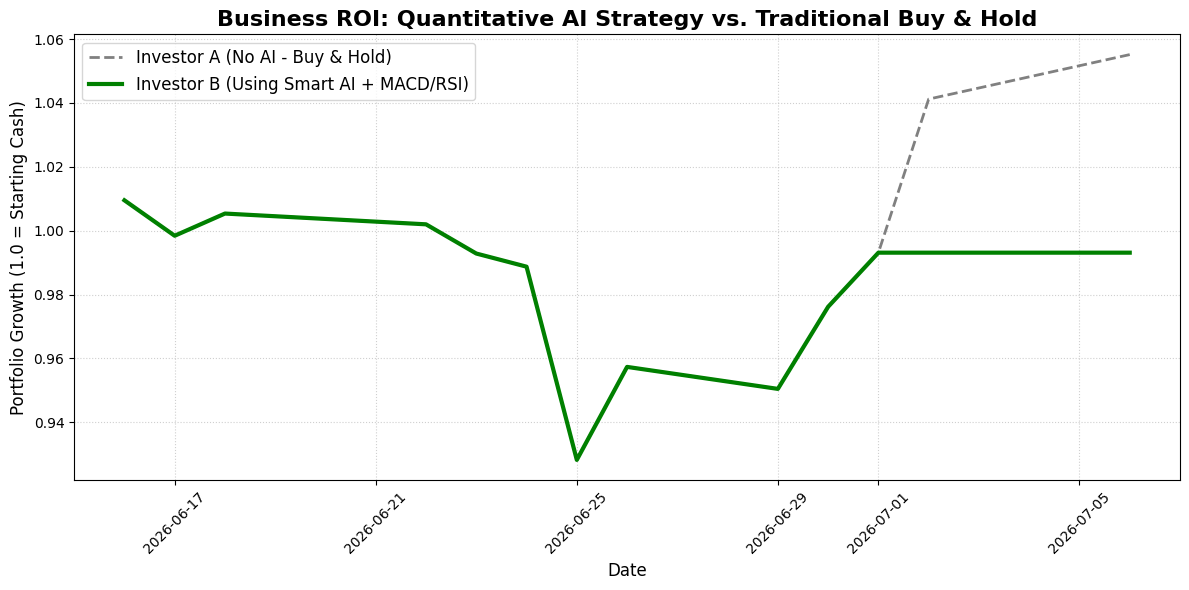

In [26]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("--- STEP 8: THE EXECUTIVE ROI CHART (SMART AI EDITION) ---")

# 1. Get the dates for our "Final Exam" period using the Smart AI's timeline
exam_indices = X_test_s.index
exam_dates = raw_data.loc[exam_indices, 'Date']

# 2. Calculate the actual daily returns as decimals
actual_returns = X_test_s['Daily_Return_Pct'] / 100

# 3. Simulate Investor A (Buy and Hold)
investor_a_money = (1 + actual_returns).cumprod()

# 4. Simulate Investor B (The AI Trader)
# 🚨 THE FIX: We are now using 'new_predictions' from the Smart AI!
ai_returns = actual_returns * new_predictions
investor_b_money = (1 + ai_returns).cumprod()

# 5. Draw the beautiful Executive Chart
plt.figure(figsize=(12, 6))

plt.plot(exam_dates, investor_a_money, label="Investor A (No AI - Buy & Hold)", color='gray', linestyle='dashed', linewidth=2)
plt.plot(exam_dates, investor_b_money, label="Investor B (Using Smart AI + MACD/RSI)", color='green', linewidth=3)

# Add business formatting
plt.title("Business ROI: Quantitative AI Strategy vs. Traditional Buy & Hold", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Portfolio Growth (1.0 = Starting Cash)", fontsize=12)
plt.legend(loc="upper left", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

print("Generating the upgraded Executive Boardroom Chart...")
plt.show()

--- STEP 10: INSIDE THE AI'S BRAIN (FEATURE IMPORTANCE) ---
Generating the Feature Importance Chart...


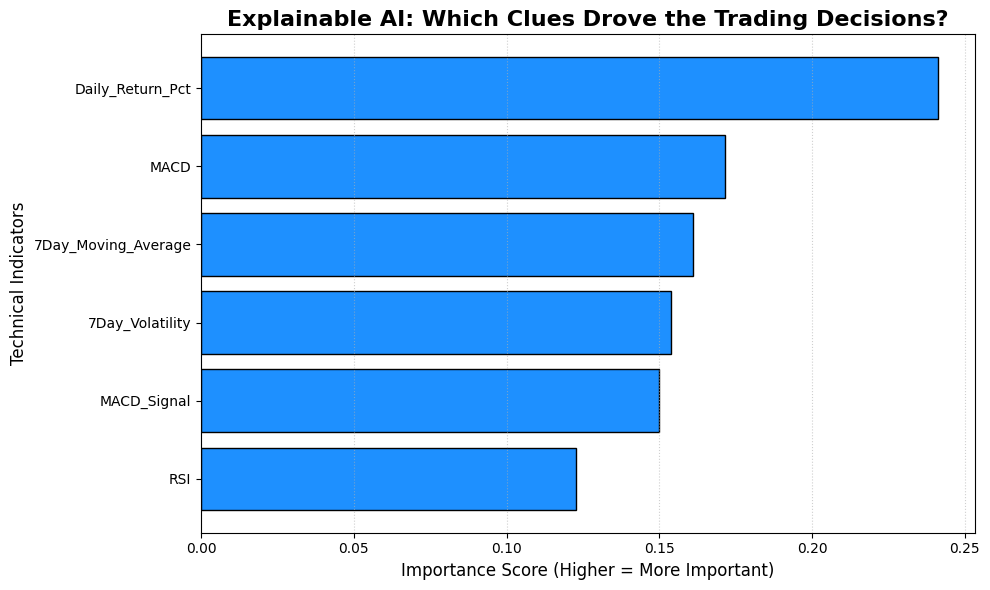

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

print("--- STEP 10: INSIDE THE AI'S BRAIN (FEATURE IMPORTANCE) ---")

# 1. Extract the "attention scores" directly from the trained Smart AI
importances = smart_ai_model.feature_importances_

# 2. Match those scores to the names of our clues (Features)
feature_names = X_smart.columns
importance_df = pd.DataFrame({
    'Financial Clue': feature_names,
    'Importance Score': importances
})

# 3. Sort them from least important to most important (so the biggest is at the top of the chart)
importance_df = importance_df.sort_values(by='Importance Score', ascending=True)

# 4. Draw a clean, professional Horizontal Bar Chart
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Financial Clue'], importance_df['Importance Score'], color='dodgerblue', edgecolor='black')

# Add business formatting
plt.title("Explainable AI: Which Clues Drove the Trading Decisions?", fontsize=16, fontweight='bold')
plt.xlabel("Importance Score (Higher = More Important)", fontsize=12)
plt.ylabel("Technical Indicators", fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()

print("Generating the Feature Importance Chart...")
plt.show()